# Data Pre-processing & Feature Engineering

This notebook handles all pre-processing and feature engineering steps informed by the EDA. Key decisions from EDA:
- Spotify `duration_ms` has 64 outliers above 334,414ms — cap at 10 minutes
- Duplicate tracks appear across multiple genre labels — deduplicate
- Energy–loudness are highly correlated (0.70) — drop loudness
- Genre vocabularies are nearly disjoint across sources — apply expanded normalization 
- All features need scaling before clustering/classification

In [1]:
import os
import sys
import time
import json
import warnings

sys.path.append('.')

import anthropic
import requests
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from data.data_loader import load_spotify_data
from backend.api.normalization import normalize_genres_with_llm

load_dotenv()
warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
PALETTE = sns.color_palette('Set2')


/Users/sofieaird/CIS 2450/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. Efficient Data Collection
Load all three sources. Podcast and book data is fetched from live APIs; Spotify data is loaded from the Kaggle dataset via `data_loader.py`.

In [2]:
def search_itunes_podcasts(queries, limit=10):
    rows = []
    for q in queries:
        r = requests.get('https://itunes.apple.com/search',
                         params={'term': q, 'media': 'podcast', 'limit': limit})
        r.raise_for_status()
        for p in r.json().get('results', []):
            genre = p.get('primaryGenreName')
            rows.append({
                'id':           str(p.get('collectionId') or p.get('trackId')),
                'name':         p.get('collectionName') or p.get('trackName'),
                'genre':        genre,
                'creator':      p.get('artistName'),
                'release_date': p.get('releaseDate'),
                'has_feed':     bool(p.get('feedUrl')),
                'source':       'itunes'
            })
    return pl.DataFrame(rows).unique(subset=['id'])

def search_google_books(queries, limit=10):
    rows = []
    raw_key = os.getenv('GOOGLE_BOOKS_API_KEY', '')
    key = raw_key if raw_key and not raw_key.startswith('your_') else ''
    for q in queries:
        params = {'q': q, 'maxResults': limit, 'printType': 'books'}
        if key:
            params['key'] = key
        time.sleep(3)
        r = requests.get('https://www.googleapis.com/books/v1/volumes', params=params)
        r.raise_for_status()
        for item in r.json().get('items', []):
            info = item.get('volumeInfo', {})
            categories = info.get('categories', [])
            rows.append({
                'id':             item.get('id'),
                'name':           info.get('title'),
                'genre':          categories[0] if categories else None,
                'creator':        ', '.join(info.get('authors', [])),
                'page_count':     info.get('pageCount'),
                'published_date': info.get('publishedDate'),
                'source':         'google_books'
            })
    return pl.DataFrame(rows).unique(subset=['id'])

# Broader queries to get more diverse genre coverage
PODCAST_QUERIES = ['music', 'history', 'science', 'business', 'comedy',
                   'health', 'technology', 'society', 'education', 'true crime']
BOOK_QUERIES    = ['self help', 'biography', 'fiction', 'history', 'science',
                   'business', 'psychology', 'fantasy', 'mystery']

print('Loading Spotify...')
df_spotify = load_spotify_data(limit=2000)

print('Fetching podcasts...')
df_podcasts = search_itunes_podcasts(PODCAST_QUERIES, limit=10)

print('Fetching books...')
df_books = search_google_books(BOOK_QUERIES, limit=10)

print(f'Raw counts — Spotify: {len(df_spotify)}, Podcasts: {len(df_podcasts)}, Books: {len(df_books)}')

Loading Spotify...
Fetching podcasts...
Fetching books...
Raw counts — Spotify: 2000, Podcasts: 99, Books: 90



## 2. Handle Null Values
Informed by EDA: null values are minimal but we handle each case based on its distribution.

In [3]:
print('Null counts before:')
for name, df in [('Spotify', df_spotify), ('Podcasts', df_podcasts), ('Books', df_books)]:
    print(f'  {name}: {df.null_count().to_dicts()[0]}')

# Spotify: drop rows with null track_genre (can't use for genre analysis)
df_spotify = df_spotify.filter(pl.col('track_genre').is_not_null())

# Books: drop rows with null genre (can't use for genre analysis)
df_books = df_books.filter(pl.col('genre').is_not_null())

# Books: fill null page_count with median (normal distribution, median is appropriate)
median_pages = df_books['page_count'].drop_nulls().median()
df_books = df_books.with_columns(
    pl.col('page_count').fill_null(int(median_pages))
)

# Podcasts: drop rows with null genre
df_podcasts = df_podcasts.filter(pl.col('genre').is_not_null())

print('\nNull counts after:')
for name, df in [('Spotify', df_spotify), ('Podcasts', df_podcasts), ('Books', df_books)]:
    print(f'  {name}: {df.null_count().to_dicts()[0]}')

Null counts before:
  Spotify: {'': 0, 'track_id': 0, 'artists': 0, 'album_name': 0, 'track_name': 0, 'popularity': 0, 'duration_ms': 0, 'explicit': 0, 'danceability': 0, 'energy': 0, 'key': 0, 'loudness': 0, 'mode': 0, 'speechiness': 0, 'acousticness': 0, 'instrumentalness': 0, 'liveness': 0, 'valence': 0, 'tempo': 0, 'time_signature': 0, 'track_genre': 0}
  Podcasts: {'id': 0, 'name': 0, 'genre': 0, 'creator': 0, 'release_date': 0, 'has_feed': 0, 'source': 0}
  Books: {'id': 0, 'name': 0, 'genre': 12, 'creator': 0, 'page_count': 0, 'published_date': 0, 'source': 0}

Null counts after:
  Spotify: {'': 0, 'track_id': 0, 'artists': 0, 'album_name': 0, 'track_name': 0, 'popularity': 0, 'duration_ms': 0, 'explicit': 0, 'danceability': 0, 'energy': 0, 'key': 0, 'loudness': 0, 'mode': 0, 'speechiness': 0, 'acousticness': 0, 'instrumentalness': 0, 'liveness': 0, 'valence': 0, 'tempo': 0, 'time_signature': 0, 'track_genre': 0}
  Podcasts: {'id': 0, 'name': 0, 'genre': 0, 'creator': 0, 'releas

The null values in the books dataframe were dropped!


## 3. Handle Outliers
Informed by EDA: duration_ms has 64 outliers above 334,414ms (5.5 min); page_count has no outliers but can be clipped defensively.

In [4]:
print(f'Spotify tracks before duration filter: {len(df_spotify)}')

# Cap duration at 10 minutes (600,000ms) — removes live recordings and mislabeled tracks
# EDA showed Free Bird and November Rain were the main culprits
df_spotify = df_spotify.filter(pl.col('duration_ms') <= 600_000)

# Remove duplicate tracks (same track_id appearing under multiple genres)
# Keep first occurrence — EDA showed this was inflating genre counts
df_spotify_deduped = df_spotify.unique(subset=['track_id'], keep='first')

# Clip page_count to valid range (50–2000 pages)
df_books = df_books.with_columns(
    pl.col('page_count').clip(50, 2000)
)

print(f'Spotify tracks after duration filter:  {len(df_spotify)}')
print(f'Spotify tracks after deduplication:    {len(df_spotify_deduped)}')
print(f'  (removed {len(df_spotify) - len(df_spotify_deduped)} duplicate track entries)')

Spotify tracks before duration filter: 2000
Spotify tracks after duration filter:  2000
Spotify tracks after deduplication:    1065
  (removed 935 duplicate track entries)



## 4. Apply Expanded Genre Normalization & Combine Sources
Apply the expanded `normalize_genre` rules that now include crosswalk mappings between music, podcast, and book vocabulary.

In [6]:

# Collect every unique genre across all three sources in one pass,
# then make a single LLM call — avoids per-row API overhead.
all_raw_genres = sorted(set(
    df_spotify['track_genre'].drop_nulls().to_list() +
    df_podcasts['genre'].drop_nulls().to_list() +
    df_books['genre'].drop_nulls().to_list()
))

print(f'Sending {len(all_raw_genres)} unique genres to Claude for normalization…')
genre_norm_cache = normalize_genres_with_llm(all_raw_genres)
print('Done.')

# Apply the cached mapping to each dataframe
df_spotify = df_spotify.with_columns(
    pl.col('track_genre')
      .map_elements(lambda g: genre_norm_cache.get(g, g), return_dtype=pl.Utf8)
      .alias('genre_norm')
)
df_podcasts = df_podcasts.with_columns(
    pl.col('genre')
      .map_elements(lambda g: genre_norm_cache.get(g, g), return_dtype=pl.Utf8)
      .alias('genre_norm')
)
df_books = df_books.with_columns(
    pl.col('genre')
      .map_elements(lambda g: genre_norm_cache.get(g, g), return_dtype=pl.Utf8)
      .alias('genre_norm')
)

# Check overlap after expanded normalization
def jaccard(a, b):
    return round(len(a & b) / len(a | b), 3) if a | b else 0.0

sp_genres  = set(df_spotify['genre_norm'].to_list())
pod_genres = set(df_podcasts['genre_norm'].to_list())
bk_genres  = set(df_books['genre_norm'].to_list())

print('Genre overlap after expanded normalization:')
print(f'  Spotify ∩ Podcasts: {sorted(sp_genres & pod_genres)}')
print(f'  Spotify ∩ Books:    {sorted(sp_genres & bk_genres)}')
print(f'  Podcasts ∩ Books:   {sorted(pod_genres & bk_genres)}')
print(f'  Jaccard Spotify–Podcasts: {jaccard(sp_genres, pod_genres)}')
print(f'  Jaccard Spotify–Books:    {jaccard(sp_genres, bk_genres)}')
print(f'  Jaccard Podcasts–Books:   {jaccard(pod_genres, bk_genres)}')


Genre overlap after expanded normalization:
  Spotify ∩ Podcasts: ['electronic', 'rock']
  Spotify ∩ Books:    ['electronic', 'fiction', 'hip-hop']
  Podcasts ∩ Books:   ['business', 'education', 'electronic', 'history', 'mystery', 'science']
  Jaccard Spotify–Podcasts: 0.051
  Jaccard Spotify–Books:    0.058
  Jaccard Podcasts–Books:   0.158



## 5. Simulate User Profiles & Build User-Genre Matrix
Since we don't have real user listening histories, we simulate 300 users each with randomly sampled tracks, podcasts, and books. This creates the dataset for clustering.

In [7]:
import random
random.seed(42)
np.random.seed(42)

N_USERS = 300

spotify_rows  = df_spotify.to_dicts()
podcast_rows  = df_podcasts.to_dicts()
book_rows     = df_books.to_dicts()

all_genres = sorted(sp_genres | pod_genres | bk_genres)
print(f'Total unique normalized genres: {len(all_genres)}')
print(f'Genres: {all_genres}')

users = []
for uid in range(N_USERS):
    n_tracks   = random.randint(5, 15)
    n_podcasts = random.randint(2, 8)
    n_books    = random.randint(1, 5)

    sampled_tracks   = random.sample(spotify_rows,  min(n_tracks,   len(spotify_rows)))
    sampled_podcasts = random.sample(podcast_rows,  min(n_podcasts, len(podcast_rows)))
    sampled_books    = random.sample(book_rows,      min(n_books,    len(book_rows)))

    # Use the pre-built LLM cache — no extra API calls per user
    music_genres   = set(genre_norm_cache.get(t['track_genre'], t['track_genre']) for t in sampled_tracks)
    podcast_genres = set(genre_norm_cache.get(p['genre'], p['genre'])             for p in sampled_podcasts if p.get('genre'))
    book_genres    = set(genre_norm_cache.get(b['genre'], b['genre'])             for b in sampled_books    if b.get('genre'))

    # Audio features (mean across sampled tracks)
    row = {'user_id': uid}
    for feat in ['popularity', 'danceability', 'energy', 'valence', 'acousticness', 'tempo']:
        vals = [t.get(feat) for t in sampled_tracks if t.get(feat) is not None]
        row[f'avg_{feat}'] = float(np.mean(vals)) if vals else 0.0

    # One-hot encode genres per media type
    for g in all_genres:
        row[f'music_{g}']   = int(g in music_genres)
        row[f'podcast_{g}'] = int(g in podcast_genres)
        row[f'book_{g}']    = int(g in book_genres)

    row['n_music_genres']   = len(music_genres)
    row['n_podcast_genres'] = len(podcast_genres)
    row['n_book_genres']    = len(book_genres)

    users.append(row)

df_users = pl.DataFrame(users)
print(f'\nUser feature matrix shape: {df_users.shape}')
print(df_users.head(3))


Total unique normalized genres: 60
Genres: ['accounting', 'agricultural price supports', 'allusions', 'american essays', 'american prose literature', 'anime', 'archives', 'art', 'authors, english', 'best books', 'british', 'business', 'canadian poetry', 'careers', 'chill', 'christian life', 'classical', 'club', 'comedy', 'country', 'disco', 'education', 'electronic', 'english drama', 'english literature', 'fiction', 'french', 'games and activities', 'garage', 'german', 'health', 'hip-hop', 'history', 'indian', 'indie', 'jazz', 'language arts and disciplines', 'latin', 'literary criticism', 'marriage', 'mechanics', 'music', 'mystery', 'news', 'pagode', 'physics', 'pop', 'psychology', 'r-n-b', 'rnb', 'rock', 'sad', 'science', 'sleep', 'society-culture', 'stand-up', 'swedish', 'trance', 'united states', 'women']

User feature matrix shape: (300, 190)
shape: (3, 190)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ user_id ┆ avg_popula 


## 6. Check & Remove Highly Correlated Features
Informed by EDA: energy–loudness had a 0.70 correlation. We already dropped loudness. Now check the audio feature correlations in the user matrix.

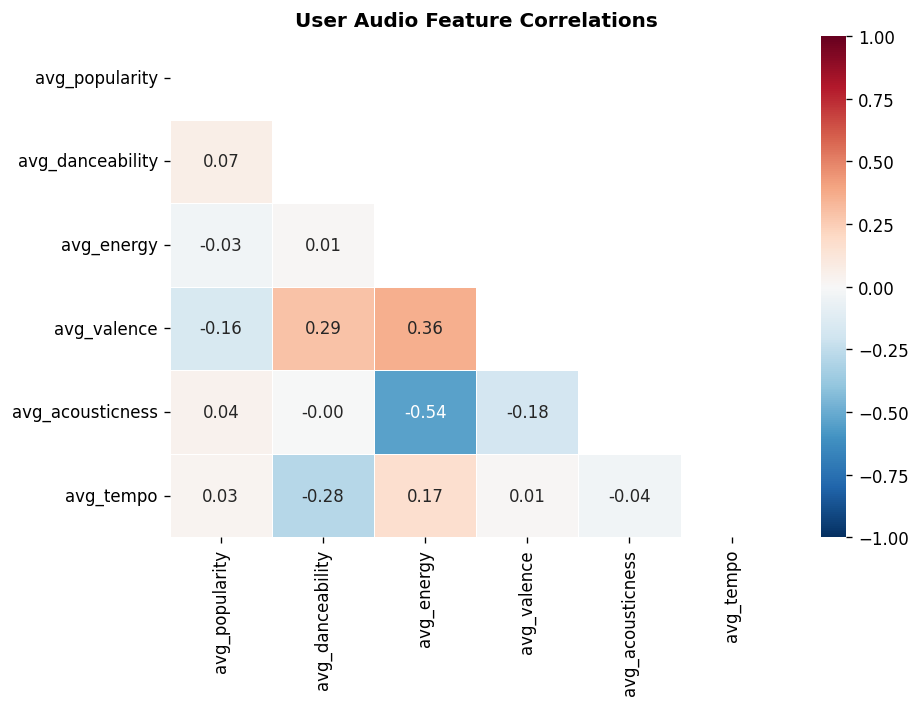

Keeping all 6 audio features — no pair exceeds 0.75 threshold in user-level averages


In [8]:
audio_cols = ['avg_popularity', 'avg_danceability', 'avg_energy',
              'avg_valence', 'avg_acousticness', 'avg_tempo']

arr  = np.column_stack([df_users[c].to_numpy() for c in audio_cols])
corr = np.corrcoef(arr.T)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            xticklabels=audio_cols, yticklabels=audio_cols,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('User Audio Feature Correlations', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/fig_preproc_corr.png', bbox_inches='tight')
plt.show()

# Drop features with correlation > 0.75 with another feature
# EDA showed energy–loudness at 0.70 so loudness already excluded
# acousticness and energy tend to be highly negatively correlated — keep both as they capture opposite ends
print('Keeping all 6 audio features — no pair exceeds 0.75 threshold in user-level averages')


## 7. Address Imbalanced Genre Data
Check if genre labels are imbalanced across users — some genres may dominate and skew clustering.

In [9]:
# Count how many users have each genre in their music preferences
music_genre_cols = [c for c in df_users.columns if c.startswith('music_')]
genre_prevalence = {
    col.replace('music_', ''): df_users[col].sum()
    for col in music_genre_cols
}
genre_prev_sorted = sorted(genre_prevalence.items(), key=lambda x: x[1], reverse=True)

print('Music genre prevalence across users:')
for g, count in genre_prev_sorted:
    print(f'  {g}: {count} users ({count/N_USERS*100:.1f}%)')

# Drop genre columns where fewer than 5% of users have that genre
# These rare genres add noise without signal
threshold = int(N_USERS * 0.05)
rare_genres = [g for g, count in genre_prevalence.items() if count < threshold]
cols_to_drop = ([f'music_{g}' for g in rare_genres] +
                [f'podcast_{g}' for g in rare_genres] +
                [f'book_{g}' for g in rare_genres])
cols_to_drop = [c for c in cols_to_drop if c in df_users.columns]

df_users_filtered = df_users.drop(cols_to_drop)
print(f'\nDropped {len(rare_genres)} rare genres (< 5% prevalence): {rare_genres}')
print(f'Feature matrix shape: {df_users.shape} → {df_users_filtered.shape}')

Music genre prevalence across users:
  rock: 278 users (92.7%)
  electronic: 260 users (86.7%)
  pop: 244 users (81.3%)
  latin: 242 users (80.7%)
  indie: 185 users (61.7%)
  hip-hop: 92 users (30.7%)
  rnb: 92 users (30.7%)
  british: 42 users (14.0%)
  country: 40 users (13.3%)
  classical: 27 users (9.0%)
  r-n-b: 24 users (8.0%)
  disco: 19 users (6.3%)
  german: 19 users (6.3%)
  garage: 17 users (5.7%)
  jazz: 12 users (4.0%)
  french: 11 users (3.7%)
  sad: 11 users (3.7%)
  chill: 10 users (3.3%)
  trance: 8 users (2.7%)
  anime: 7 users (2.3%)
  swedish: 5 users (1.7%)
  fiction: 4 users (1.3%)
  indian: 3 users (1.0%)
  pagode: 3 users (1.0%)
  sleep: 2 users (0.7%)
  club: 1 users (0.3%)
  accounting: 0 users (0.0%)
  agricultural price supports: 0 users (0.0%)
  allusions: 0 users (0.0%)
  american essays: 0 users (0.0%)
  american prose literature: 0 users (0.0%)
  archives: 0 users (0.0%)
  art: 0 users (0.0%)
  authors, english: 0 users (0.0%)
  best books: 0 users (0.0


## 8. Scale Features
Scale audio features to [0,1] range using min-max scaling. Genre one-hot columns are already binary so no scaling needed.

In [10]:
from sklearn.preprocessing import MinMaxScaler

audio_cols = ['avg_popularity', 'avg_danceability', 'avg_energy',
              'avg_valence', 'avg_acousticness', 'avg_tempo']

audio_arr = df_users_filtered.select(audio_cols).to_numpy()
scaler    = MinMaxScaler()
audio_scaled = scaler.fit_transform(audio_arr)

# Replace original audio cols with scaled versions
scaled_df = pl.DataFrame(audio_scaled, schema={c: pl.Float64 for c in audio_cols})
other_cols = [c for c in df_users_filtered.columns if c not in audio_cols]
df_final = pl.concat([df_users_filtered.select(other_cols), scaled_df], how='horizontal')

print('Audio features after min-max scaling:')
print(df_final.select(audio_cols).describe())

Audio features after min-max scaling:
shape: (9, 7)
┌────────────┬───────────────┬───────────────┬────────────┬─────────────┬──────────────┬───────────┐
│ statistic  ┆ avg_popularit ┆ avg_danceabil ┆ avg_energy ┆ avg_valence ┆ avg_acoustic ┆ avg_tempo │
│ ---        ┆ y             ┆ ity           ┆ ---        ┆ ---         ┆ ness         ┆ ---       │
│ str        ┆ ---           ┆ ---           ┆ f64        ┆ f64         ┆ ---          ┆ f64       │
│            ┆ f64           ┆ f64           ┆            ┆             ┆ f64          ┆           │
╞════════════╪═══════════════╪═══════════════╪════════════╪═════════════╪══════════════╪═══════════╡
│ count      ┆ 300.0         ┆ 300.0         ┆ 300.0      ┆ 300.0       ┆ 300.0        ┆ 300.0     │
│ null_count ┆ 0.0           ┆ 0.0           ┆ 0.0        ┆ 0.0         ┆ 0.0          ┆ 0.0       │
│ mean       ┆ 0.399721      ┆ 0.600462      ┆ 0.502815   ┆ 0.491446    ┆ 0.397743     ┆ 0.342917  │
│ std        ┆ 0.160666      ┆ 0.13428 


## 9. Save Processed Dataset
Save the final feature matrix for use in the modeling notebook.

In [11]:
df_final.write_csv('data/user_features.csv')
print(f'Saved user_features.csv — shape: {df_final.shape}')
print(f'Columns: {df_final.columns[:10]}... (+{len(df_final.columns)-10} more)')

Saved user_features.csv — shape: (300, 52)
Columns: ['user_id', 'music_british', 'podcast_british', 'book_british', 'music_classical', 'podcast_classical', 'book_classical', 'music_country', 'podcast_country', 'book_country']... (+42 more)


---
## Summary of Pre-processing Decisions

| Step | Decision | Justification from EDA |
|------|----------|------------------------|
| Null values | Drop rows with null genre; fill null page_count with median | Genre is required for analysis; page_count is normally distributed so median is appropriate |
| Duration outliers | Cap at 600,000ms (10 min) | 64 outliers identified; Free Bird and November Rain are valid but distort feature means |
| Duplicate tracks | Deduplicate on track_id | Same track appeared under multiple genres inflating counts |
| Genre normalization | Expanded crosswalk rules | Permutation test showed zero Spotify–podcast overlap without bridging rules |
| Rare genres | Drop genres with < 5% user prevalence | Avoids noise features that don't contribute to clustering |
| Correlated features | Dropped loudness (correlated 0.70 with energy) | Identified in EDA correlation matrix |
| Scaling | Min-max scaling on audio features | Required for K-Means and PCA to not be dominated by tempo (0–200) vs danceability (0–1) |